In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer


In [2]:
df=pd.read_csv(r"d:\Downloads_ML_aaa\train.csv",usecols=["Age","Fare","Survived"])
df["Age"]=df["Age"].fillna(df["Age"].mean())

In [3]:
X=df.iloc[:,1:3]
y=df["Survived"]


In [4]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=23)


Text(0.5, 1.0, 'Fare QQ(probability plot)')

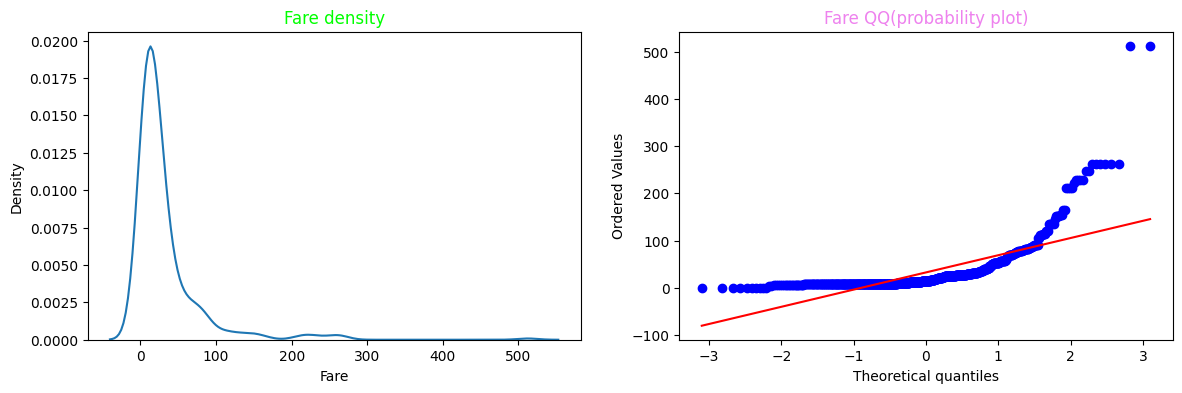

In [43]:
fig,ax=plt.subplots(1,2,figsize=(14,4))
sns.kdeplot(X_train["Fare"],ax=ax[0])
ax[0].set_title("Fare density",color="lime")

ax[1]
stats.probplot(X_train["Fare"],dist="norm",plot=plt)
ax[1].set_title("Fare QQ(probability plot)", color="violet")


[]

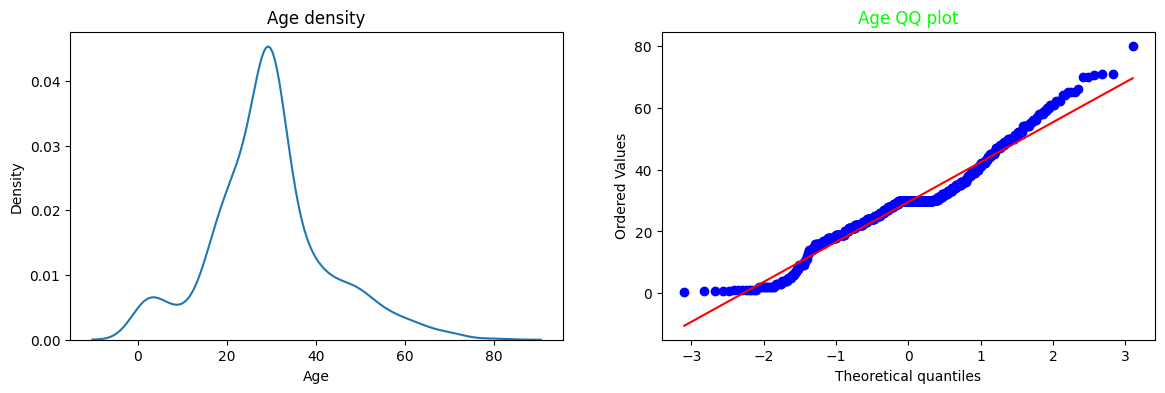

In [41]:
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
sns.kdeplot(X_train["Age"])
plt.title("Age density")
plt.plot()
plt.subplot(1,2,2)
stats.probplot(X_train["Age"],dist="norm",plot=plt)
plt.title("Age QQ plot",color="lime")
plt.plot()

## training model without maikign the distribution normal

In [45]:
model1=LogisticRegression()
model2=DecisionTreeClassifier()

In [58]:
model1.fit(X_train,y_train)
model2.fit(X_train,y_train)

y_pred1=model1.predict(X_test)
y_pred2=model2.predict(X_test)


print("Accuracy_score_model1:",accuracy_score(y_test,y_pred1))
print("Accuracy_score_model2:",accuracy_score(y_test,y_pred2))

Accuracy_score_model1: 0.6759776536312849
Accuracy_score_model2: 0.6480446927374302


## with function transformer

In [50]:
trf=FunctionTransformer(func=np.log1p)

In [ ]:
X_train_transformed=trf.fit_transform(X_train)
X_test_transfomed=trf.transform(X_test)

In [71]:
model_1=LogisticRegression()
model_2=DecisionTreeClassifier()

model_1.fit(X_train_transformed,y_train)
model_2.fit(X_train_transformed,y_train)

pred1=model_1.predict(X_test_transfomed)
pred2=model_2.predict(X_test_transfomed)

print("Accuracy_score_model1:",accuracy_score(y_test,pred1))
print("Accuracy_score_model2:",accuracy_score(y_test,pred2))

Accuracy_score_model1: 0.7318435754189944
Accuracy_score_model2: 0.6312849162011173


### observations
### Decision trees is not affected much by function transform 
### but algos like logistic regression become better